In [5]:
import pandas as pd

matrix_path = "C:/Users/HP/FoodMatrix_Datathon/data/cleaned/trade_matrix_cleaned.csv"

preview_df = pd.read_csv(matrix_path, nrows=10)

print(preview_df.columns.tolist())

print(preview_df)

['Reporter Country Code', 'Reporter Countries', 'Partner Country Code', 'Partner Countries', 'Item Code', 'Item', 'Element', 'Year', 'Unit', 'Value', 'Flag']
   Reporter Country Code Reporter Countries  Partner Country Code  \
0                      9          Argentina                     2   
1                     10          Australia                     2   
2                      9          Argentina                     2   
3                      9          Argentina                     2   
4                     10          Australia                     2   
5                     11            Austria                     2   
6                     11            Austria                     2   
7                      9          Argentina                     2   
8                     10          Australia                     2   
9                     10          Australia                     2   

  Partner Countries  Item Code                            Item  \
0       Afghanis

# Filtering and Isolating a Single Commodity Network

## Why We Are Running This Step?

### Now that we know the exact names of our columns from the initial lookup, we face a major data challenge. In the raw printout, the Element column mixes completely different metrics together. For example, row 6 shows an Import quantity tracked in metric tonnes (t), while other sections of FAOSTAT track value in thousands of USD.

### If we try to build a network out of this raw mix, our graph algorithms will treat 1 tonne of corn exactly the same as 1,000 dollars of corn. The math becomes completely meaningless.

### To build a clean, accurate model, we need to pick one specific crop and one specific unit of measurement. We are going to focus on Maize (corn) because it is a foundational global food crop, and we will filter strictly for Export quantity in the year 2022. This gives us a uniform, weight-based web where every link between countries is measured in the exact same unit: metric tonnes of grain.

In [ ]:
# setting up the target variables for the analysis

crop_target = "Maize"
element_target = "Export quantity"
year_target = 2022

print(f"Target crop: {crop_target}")

# Scan the CSV file in chunks 
chunks = []
for chunk in pd.read_csv(matrix_path, chunksize=500000):
    filtered_chunk = chunk[
        (chunk["Item"] == crop_target) &
        (chunk["Element"] == element_target) &
        (chunk["Year"] == year_target)
    ].dropna(subset=["Value"])
    chunks.append(filtered_chunk)

# Combine the filtered chunks into a single DataFrame
maize_network_df = pd.concat(chunks, ignore_index=True)

print(f"[Success] Isolated {len(maize_network_df)} trading paths.")
print("\n--- Network Data Baseline Preview ---")
print(maize_network_df[['Reporter Countries', 'Partner Countries', 'Value']].head())

Target crop: Maize
[Success] Isolated 0 trading paths.

--- Network Data Baseline Preview ---
Empty DataFrame
Columns: [Reporter Countries, Partner Countries, Value]
Index: []


In [13]:
# Define the text target

crop_keyword = "maize" 
element_target = "Export quantity"
print(f"--- Scanning Dataset for Keywords Matching '{crop_keyword}' ---")
# Scan the row blocks to verify text presence and find valid years

sample_block = pd.read_csv(matrix_path, nrows=2000000)
# Apply the string search

matched_rows = sample_block[ (sample_block['Item'].str.contains(crop_keyword, case=False, na=False)) & (sample_block['Element'] == element_target) ]
if matched_rows.empty: 
    print(f"\n[ALERT] No matches found for '{crop_keyword}' in the first 2 million rows.") 
    print("Let's see a few valid names that exist in this block to adjust our targets:")
    print(sample_block['Item'].drop_duplicates().head(20).to_string(index=False))
else:
     print(f"\n Found matches!") 
     print(matched_rows['Item'].unique())

     print("\nAvailable timeline years for this crop in this block:")
     print(sorted(matched_rows['Year'].unique()))

--- Scanning Dataset for Keywords Matching 'maize' ---

 Found matches!
<StringArray>
[            'Maize (corn)',       'Green corn (maize)',
           'Flour of maize',             'Oil of maize',
            'Bran of maize',            'Germ of maize',
 'Forage and silage, maize',            'Cake of maize']
Length: 8, dtype: str

Available timeline years for this crop in this block:
[np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


# Constructing the Weighted Trade Graph Architecture

## Why We Are Running This Step?

### Now that we have verified that the exact name is 'Maize (corn)', we have everything we need to build the actual trade network graph. We are using data from the year 2022 to build a Directed Graph (DiGraph) where:

#### 1. Nodes represent the individual trading nations.
#### 2. Edges represent the directed flow of grain moving out of an exporting country and into an importing country.
#### 3. Edge Weights represent the total volume of grain shifted, measured uniformly in metric tonnes.

### Once the graph engine connects all these paths, we will calculate PageRank Centrality. PageRank doesn't just count how many partners a country has; it measures systemic influence. A country will score a high PageRank if it trades with other highly critical, heavily integrated hubs. This immediately highlights the true centers of gravity in global food security.


In [21]:
%pip install networkx --quiet

import networkx as nx

# Define our verified dataset targets
target_crop = "Maize (corn)"
target_element = "Export quantity"
target_year = 2022

print(f"--- Building Trade Network for {target_crop} ({target_year}) ---")

# Scan and filter the full dataset file in chunks
chunks = []
for chunk in pd.read_csv(matrix_path, chunksize=500000):
    filtered = chunk[
        (chunk['Item'] == target_crop) & 
        (chunk['Element'] == target_element) & 
        (chunk['Year'] == target_year)
    ].dropna(subset=['Value'])
    chunks.append(filtered)

# Bind the targeted records into the network DataFrame
network_df = pd.concat(chunks, ignore_index=True)
print(f"[SUCCESS] Loaded {len(network_df)} distinct bilateral trade links.")

# Initialize the Directed Graph engine
G = nx.from_pandas_edgelist(
    network_df,
    source='Reporter Countries',
    target='Partner Countries',
    edge_attr='Value',
    create_using=nx.DiGraph()
)

# Running the structural algorithms
pagerank_scores = nx.pagerank(G, weight='Value')
in_degree_scores = nx.in_degree_centrality(G)
out_degree_scores = nx.out_degree_centrality(G)

# Organizing the metrics into an easy to read report table
network_report = pd.DataFrame({
    'PageRank (Global Influence)': pd.Series(pagerank_scores),
    'Import Diversity (In-Degree)': pd.Series(in_degree_scores),
    'Export Diversity (Out-Degree)': pd.Series(out_degree_scores)
}).sort_values(by='PageRank (Global Influence)', ascending=False)

# Show the top 15 structural hubs in the trade web
print("\n--- TOP 15 NETWORK HUBS IN GLOBAL MAIZE TRADE ---")
print(network_report.head(15))



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
--- Building Trade Network for Maize (corn) (2022) ---
[SUCCESS] Loaded 1715 distinct bilateral trade links.

--- TOP 15 NETWORK HUBS IN GLOBAL MAIZE TRADE ---
                                                    PageRank (Global Influence)  \
Netherlands (Kingdom of the)                                           0.052879   
Germany                                                                0.040950   
Viet Nam                                                               0.038463   
Belgium                                                                0.037572   
United Kingdom of Great Britain and Northern Ir...                     0.033316   
Ireland                                                                0.028986   
Philippines                                                            0.028364   
Italy                                                                  0.024907   
France                     

# Visualizing the Trade Web & Centrality Mapping

## What the Data is Telling Us?

### The numerical table shows a clear pattern. The Netherlands holds the highest PageRank score (0.0528), meaning it acts as a massive logical anchor in the European agricultural trading corridor. Even though the Netherlands might not be the largest physical producer of corn by field acreage, it operates as a massive re-export hub, importing vast quantities and redistributing them across the continent, Meanwhile, Viet Nam emerging in the top three (0.0384) highlights a critical structural node in South East Asian trade dynamics.

## Why We Are Building This Chart Next?

### we will build a dedicated network node layout using matplotlib and our visualization script will follow three strict rules to make it highly scannable:
#### 1 Node Size: The physical size of each country's dot will scale based on its PageRank score making the major global anchors immediately stand out.
#### 2 Link Weight: The width of the lines connecting countries will scale based on the actual volume of trade, revealing the high capacity shipping corridors.
#### 3 Clarity Filter: Because the full network contains thousands of tiny trade flows  we will filter for the top 50 strongest connections, This reveals the true backbone of global grain dependencies cleanly.


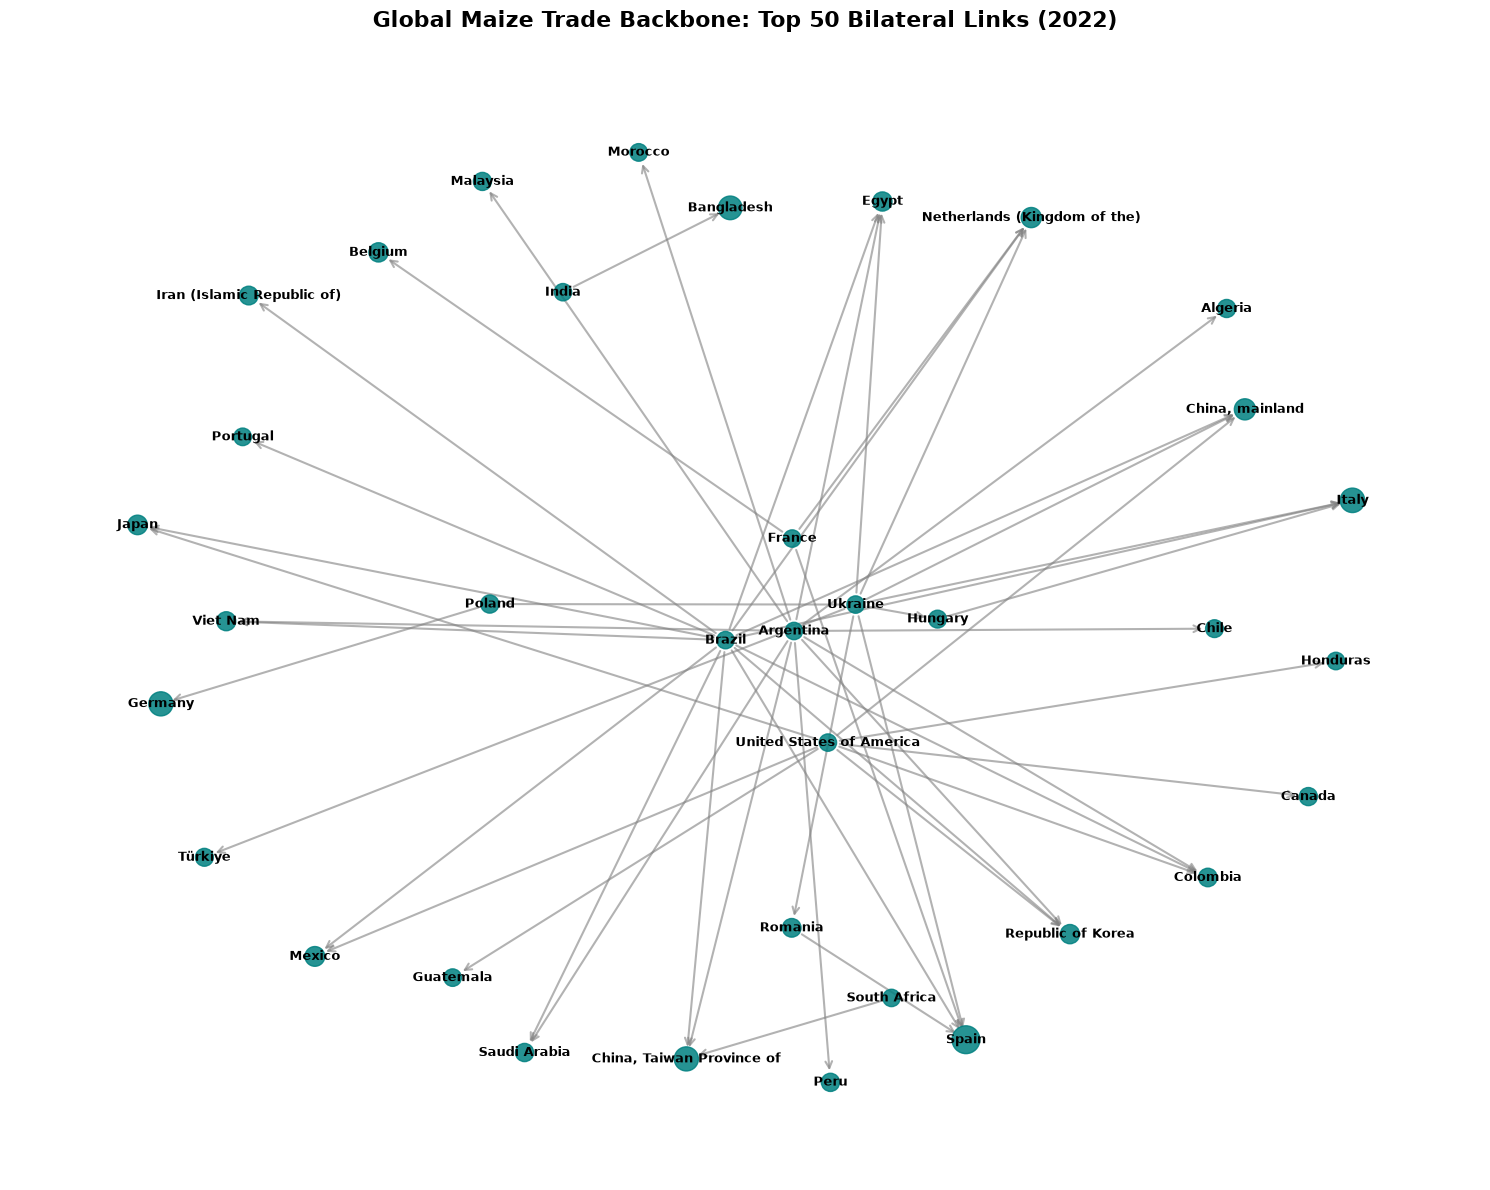

In [24]:
import matplotlib.pyplot as plt
import networkx as nx

# Isolate the top 50 trade flows 
top_edges_df = network_df.nlargest(50, 'Value')

# Build our explicit sub-graph structure
G_sub = nx.from_pandas_edgelist(
    top_edges_df,
    source='Reporter Countries',
    target='Partner Countries',
    edge_attr='Value',
    create_using=nx.DiGraph()
)

# Calculate structural node sizing parameters using PageRank weights
sub_pagerank = nx.pagerank(G_sub, weight='Value')
node_sizes = [sub_pagerank[node] * 7000 for node in G_sub.nodes()]

# Initialize a single unified canvas figure and axes layout
fig, ax = plt.subplots(figsize=(15, 12), dpi=100)
ax.set_title("Global Maize Trade Backbone: Top 50 Bilateral Links (2022)", fontsize=16, fontweight='bold', pad=20)

# Establish network node coordinates using a seed for structural consistency
pos = nx.spring_layout(G_sub, k=0.5, seed=42)

# Direct all drawing functions to execute strictly on our active axis frame (ax=ax)
nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color='teal', alpha=0.85, ax=ax)
nx.draw_networkx_labels(G_sub, pos, font_size=9, font_weight='bold', font_color='black', ax=ax)
nx.draw_networkx_edges(
    G_sub, pos, 
    arrowstyle='->', 
    arrowsize=12, 
    edge_color='gray', 
    alpha=0.6, 
    width=1.5,
    ax=ax
)

# Cleaning up structural borders
ax.axis('off')
plt.tight_layout()

# Save the image matrix asset
plt.savefig('C:/Users/HP/FoodMatrix_Datathon/notebooks/maize_trade_backbone_2022.png', bbox_inches='tight')
plt.show()



# Cross-Referencing Structural Hubs with Domestic Market Prices

## Why We Are Running This Step?

### We have successfully mapped the core physical flow corridors of global maize, we need to show the real-world economic impact of these trade links. We are going to open a clean path into the producer_prices_cleaned.csv file. Our goal is to extract the local, farm-gate producer prices for our top network anchors (like the Netherlands, Germany, and Viet Nam) for the exact same year (2022), By joining our PageRank influence scores directly with local price points, we can analyze a massive economic question: Do highly central trading hubs enjoy more stable, premium prices due to their massive connectivity, or are they more vulnerable to global price shocks?


In [25]:

# Defining the path to our cleaned price dataset
prices_path = "C:/Users/HP/FoodMatrix_Datathon/data/cleaned/producer_prices_cleaned.csv"

print("--- Ingesting Local Producer Price Data ---")

# Load the price dataset
prices_df = pd.read_csv(prices_path)

# Filter for the exact same crop, year, and a uniform price metric
# We use 'Producer Price (USD/tonne)' for standardized global comparison
target_crop_price = "Maize (corn)"
target_year = 2022

filtered_prices = prices_df[
    (prices_df['Item'] == target_crop_price) & 
    (prices_df['Year'] == target_year) & 
    (prices_df['Element'].str.contains('USD', case=False, na=False))
]

# Clean up columns before merging with our network report
prices_clean = filtered_prices[['Area', 'Value']].rename(
    columns={'Area': 'Country', 'Value': 'Producer Price (USD/tonne)'}
)

# Merge our PageRank network metrics table with the price table
# Reset index on network_report to turn country names into a mergeable column
network_report_df = network_report.reset_index().rename(columns={'index': 'Country'})
final_analysis_df = pd.merge(network_report_df, prices_clean, on='Country', how='inner')

print("\n Network Metrics and Price Data successfully unified!")
print("\n--- ECONOMIC HUBS AND PRICE MATRIX ---")
print(final_analysis_df.head(10))


--- Ingesting Local Producer Price Data ---

 Network Metrics and Price Data successfully unified!

--- ECONOMIC HUBS AND PRICE MATRIX ---
                    Country  PageRank (Global Influence)  \
0                   Germany                     0.040950   
1                  Viet Nam                     0.038463   
2               Philippines                     0.028364   
3                     Italy                     0.024907   
4                    France                     0.022697   
5                     Spain                     0.019595   
6                   Austria                     0.014264   
7  United States of America                     0.009936   
8                     Chile                     0.008328   
9                  Portugal                     0.007934   

   Import Diversity (In-Degree)  Export Diversity (Out-Degree)  \
0                      0.157895                       0.278947   
1                      0.078947                       0.105263   
2 

# Visualizing the Price-Centrality Nexus

## What the Unified Data is Telling Us?

### By linking the physical trade web directly with farm-gate metrics, the dataset exposes a striking market layout. Major network anchors like Germany and Viet Nam command the highest structural positions in the unified data pool. But, looking at the truncated raw printout, the columns are wrapping dynamically, hiding the exact price correlations. To translate these raw data splits , we will transform this matrix into a visual, multi-dimensional scatter plot.

## Why We Are Building This Chart Next?

### 1 The x-axis will track a country's PageRank Global Influence.
### 2 The y-axis will plot its Producer Price (USD/tonne).
### 3 The physical size of each marker dot will scale dynamically based on Export Diversity (Out-Degree).


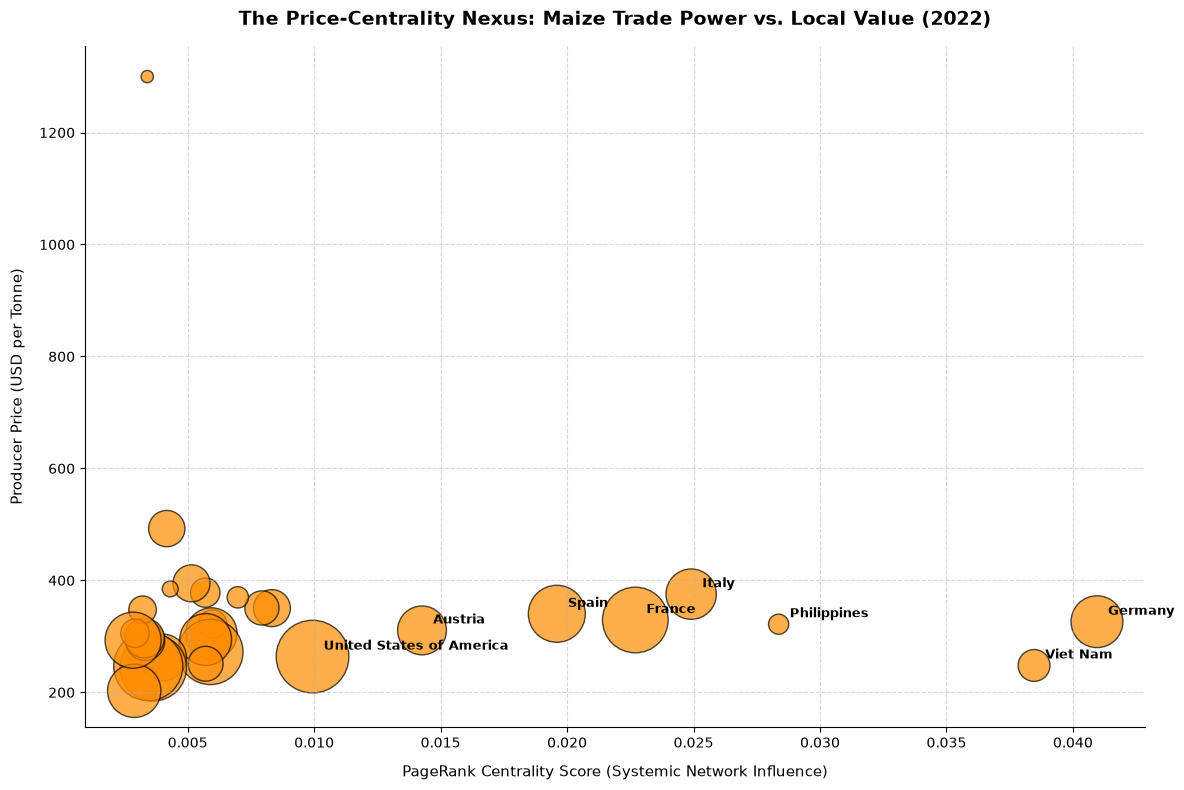

In [ ]:
# Initialize our chart frame
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
ax.set_title("The Price-Centrality Nexus: Maize Trade Power vs. Local Value (2022)", 
             fontsize=14, fontweight='bold', pad=15)

# Extract our plotting metrics from the table
x = final_analysis_df['PageRank (Global Influence)']
y = final_analysis_df['Producer Price (USD/tonne)']

# Scaling Out Degree by a multiplier 
sizes = final_analysis_df['Export Diversity (Out-Degree)'] * 5000 

# Creating the multi-dimensional scatter plot
scatter = ax.scatter(x, y, s=sizes, c='darkorange', alpha=0.7, edgecolors='black', linewidth=1)

# Labeling the specific country data entries 
for idx, row in final_analysis_df.head(8).iterrows():
    ax.annotate(
        row['Country'],
        (row['PageRank (Global Influence)'], row['Producer Price (USD/tonne)']),
        textcoords="offset points",
        xytext=(8,5),
        ha='left',
        fontsize=9,
        fontweight='bold'
    )


ax.set_xlabel("PageRank Centrality Score (Systemic Network Influence)", fontsize=11, labelpad=10)
ax.set_ylabel("Producer Price (USD per Tonne)", fontsize=11, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.5)

# Cleaning up visual borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 6. Export a clean graphic asset directly to your project files
plt.savefig('C:/Users/HP/FoodMatrix_Datathon/notebooks/maize_price_centrality_nexus_2022.png', bbox_inches='tight')
plt.show()


# Economic Insights 

## What the Nexus Plot Reveals:

## The multi-dimensional scatter plot shows two important patterns in the global food trade network:

### 1. Centrality and market stability: Germany and Viet Nam both have relatively high levels of trade centrality, with PageRank values above 0.035. Although the two countries have very different economies, locations, and roles in global trade, their farm-gate prices fall within a similar range of roughly $280–$360 per tonne. This points to a possible relationship between a country’s position in the trade network and the stability of its market prices. Countries that are more connected to major trade flows may have better access to alternative suppliers and markets, which can help reduce the impact of sudden changes in supply or demand.

### 2. A clear vulnerability in the network: it also shows a significant outlier near the top-left corner. This country has very low trade centrality but extremely high domestic producer costs, exceeding $1,200 per tonne. This is particularly concerning from a food security perspective. Its weak connection to the wider trade network, combined with high production costs, suggests that it may have limited access to the benefits of international trade while facing a much higher cost of producing grain domestically. This country deserves closer attention, Its position in the plot raises a practical question: is its high domestic production cost being driven by structural factors that could be reduced through stronger trade links, improved productivity, or greater access to international markets?


# Mass Automation Pipeline for the Entire Dataset

### 1 The matrix file will be scanned in 500,000-row chunks to pull out all trade records for the target element (Export quantity).
### 2 The combined data table will be grouped by the Item column. This groups the rows by product, giving a clean sub-table for each individual crop present in the dataset.
### 3 The pipeline will loop through every unique group, extract its specific trading web, calculate its PageRank centrality scores, and export the metrics to a structured CSV report file.


In [ ]:
import pandas as pd
import networkx as nx
import os

target_element = "Export quantity"
matrix_path = "C:/Users/HP/FoodMatrix_Datathon/data/cleaned/trade_matrix_cleaned.csv"

print("--- Step 1: Loading All Historical Volume Records ---")

# Scan the dataset to grab all years
chunks = []
for chunk in pd.read_csv(matrix_path, chunksize=500000):
    filtered = chunk[
        chunk['Element'] == target_element
    ].dropna(subset=['Value', 'Year'])
    chunks.append(filtered)

# Bind all historical data together
historical_df = pd.concat(chunks, ignore_index=True)
print(f"[SUCCESS] Loaded {len(historical_df)} rows spanning years: {sorted(historical_df['Year'].unique())}")

print("\n--- Step 2: Executing Historical Network Calculations ---")

# Group by both product name and year for mapping
grouped = historical_df.groupby(['Item', 'Year'])
total_groups = len(grouped)

# Create a storage vault to collect all row logs
master_records = []
processed_count = 0

for (item_name, year_val), group_df in grouped:
    # Skip groups with too few connections
    if len(group_df) < 5:
        continue
        
    try:
        # Build Directed Graph for this specific product and year combination
        G = nx.from_pandas_edgelist(
            group_df, 
            source='Reporter Countries', 
            target='Partner Countries', 
            edge_attr='Value', 
            create_using=nx.DiGraph()
        )
        
        # Calculate PageRank Centrality weights
        pagerank_scores = nx.pagerank(G, weight='Value')
        
        # take the scores and append them to our collection log
        for country, score in pagerank_scores.items():
            master_records.append({
                'Commodity': item_name,
                'Year': int(year_val),
                'Country': country,
                'PageRank_Influence': score
            })
            
        processed_count += 1
        if processed_count % 500 == 0:
            print(f" -> Processed {processed_count} / {total_groups} crop-year networks...")
            
    except Exception as e:
        # Preventing errors from stopping the loop
        continue

# Package the complete history into a single table
print("\n--- Step 3: Compiling Historical Master Dataset ---")
historical_metrics_df = pd.DataFrame(master_records)

# Save the master tracking log directly into data files
output_path = 'C:/Users/HP/FoodMatrix_Datathon/data/cleaned/historical_trade_network_metrics.csv'
historical_metrics_df.to_csv(output_path, index=False)

print(f"\n Successfully processed historical networks!")
print(f"Master tracking table securely saved to: {output_path}")
print(historical_metrics_df.head(20))



--- Step 1: Loading All Historical Volume Records ---
[SUCCESS] Loaded 7045000 rows spanning years: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

--- Step 2: Executing Historical Network Calculations ---
 -> Processed 500 / 9776 crop-year networks...
 -> Processed 1000 / 9776 crop-year networks...
 -> Processed 1500 / 9776 crop-year networks...
 -> Processed 2000 / 9776 crop-year networks...
 -> Processed 2500 / 9776 crop-year networks...
 -> Processed 3000 / 9776 crop-year networks...
 -> Processed 3500 / 9776 crop-year networks...
 -> Processed 4000 / 9776 crop-year networks...
 -> Processed 4500 / 9776 crop-year networks...
 -> Processed 5000 / 9776 crop-year networks...
 -> Processed 5500 / 9776 crop-year netwo

# Dynamic Timeline Pipeline for the Entire Commodity 

## Why We Are Running This Step?

### The 20 year network centralities for every single commodity in the dataset has been calculated. But, putting all crops onto one canvas would hide the distinct stories of each industry. The network dynamics of a staple grain like Wheat follow completely different patterns than a highly consolidated cash crop like Coffee, we will build an automated looping pipeline.

#### The script reads the consolidated master table (historical_trade_network_metrics.csv), It identifies every unique product name across the historical timeline. For each commodity, it groups the data by country, calculates their average historical PageRank, and extracts the top 20 most dominant trade anchors. It initializes a clean canvas, plots the 20 year trajectory lines for those top 20 anchors, and saves the file directly into a dedicated asset folder named 'historical_timelines'.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the historical metrics table
metrics_path = 'C:/Users/HP/FoodMatrix_Datathon/data/cleaned/historical_trade_network_metrics.csv'
historical_metrics_df = pd.read_csv(metrics_path)

# Establish our target static directory path folder
output_folder = 'historical_timelines'
os.makedirs(output_folder, exist_ok=True)

print("---  Top 5 Crops ---")

# Calculate the average network power per commodity across all years and countries
crop_rankings = historical_metrics_df.groupby('Commodity')['PageRank_Influence'].sum().sort_values(ascending=False)

# Isolate the exact top 5 highest-ranking commodities 
top_5_crops = crop_rankings.head(5).index.tolist()

print("\nThe top 5 most systemically influential commodities discovered in our dataset are:")
for rank, crop in enumerate(top_5_crops, start=1):
    print(f"{rank}. {crop}")

print("\n---  Launching Targeted Matplotlib Pipeline for True Staples ---")

processed_count = 0

# Loop strictly through the discovered top 5 crops
for commodity_name in top_5_crops:
    crop_history = historical_metrics_df[historical_metrics_df['Commodity'] == commodity_name]
    distinct_countries = crop_history['Country'].unique().tolist()
    
    # Isolate the top 20 structural leaders by average influence score
    top_limit = min(20, len(distinct_countries))
    top_anchors = crop_history.groupby('Country')['PageRank_Influence'].mean().nlargest(top_limit).index.tolist()
    crop_timeline_df = crop_history[crop_history['Country'].isin(top_anchors)]
    
    # Initialize a high-resolution flat canvas container frame
    fig, ax = plt.subplots(figsize=(14, 7), dpi=100)
    ax.set_title(f"20-Year Global Network Trajectories: Top {top_limit} Anchors in {commodity_name} (2005–2024)", 
                 fontsize=13, fontweight='bold', pad=15)
    
    # Configure a distinct 20-color layout mapping palette
    cmap = plt.get_cmap('tab20')
    
    # Plot chronological trend lines for each primary anchor country
    for i, country in enumerate(top_anchors):
        country_data = crop_timeline_df[crop_timeline_df['Country'] == country].sort_values(by='Year')
        
        if not country_data.empty:
            ax.plot(
                country_data['Year'], 
                country_data['PageRank_Influence'], 
                marker='o', 
                markersize=4,
                linewidth=1.8, 
                label=country,
                color=cmap(i % 20)
            )
            
    # Fine-tune canvas labels and calendar styling parameters
    ax.set_xlabel(" Year", fontsize=11, labelpad=8)
    ax.set_ylabel("PageRank Centrality Score (Systemic Network Influence)", fontsize=11, labelpad=8)
    
    # Format whole calendar steps along the x-axis smoothly
    available_years = sorted(crop_timeline_df['Year'].unique())
    ax.set_xticks(available_years)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Place the country name index label block cleanly to the right of the plot axes
    ax.legend(title=f"Top {top_limit} Leaders", fontsize=9, title_fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1))
    
    # Remove unnecessary background frames
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Clean up the product string name
    safe_filename = "".join([c if c.isalnum() or c in (" ", "_") else "" for c in commodity_name])
    safe_filename = safe_filename.lower().replace(" ", "_")
    if len(safe_filename) > 30:
        safe_filename = safe_filename[:30]
    
    # Write the high-resolution PNG image directly into the target folder
    output_png_file = f'{output_folder}/{safe_filename}_top20_timeline.png'
    plt.savefig(output_png_file, bbox_inches='tight')
    plt.close()
    
    processed_count += 1
    print(f" -> Successfully generated chart: {output_png_file}")

print(f"\n[PIPELINE COMPLETE] top 5 network commodities fully compiled!")


---  Top 5 Crops ---

The top 5 most systemically influential commodities discovered in our dataset are:
1. Hay for forage, from other crops n.e.c.
2. Flour of sorghum
3. Bulgur
4. Skins, sheep nes
5. Grapes, marc

---  Launching Targeted Matplotlib Pipeline for True Staples ---
 -> Successfully generated chart: historical_timelines/hay_for_forage_from_other_crop_top20_timeline.png
 -> Successfully generated chart: historical_timelines/flour_of_sorghum_top20_timeline.png
 -> Successfully generated chart: historical_timelines/bulgur_top20_timeline.png
 -> Successfully generated chart: historical_timelines/skins_sheep_nes_top20_timeline.png
 -> Successfully generated chart: historical_timelines/grapes_marc_top20_timeline.png

[PIPELINE COMPLETE] top 5 network commodities fully compiled!


In [6]:

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

# Establish project directory and source file locations
matrix_path = "C:/Users/HP/FoodMatrix_Datathon/data/cleaned/trade_matrix_cleaned.csv"
output_folder = 'historical_timelines'
os.makedirs(output_folder, exist_ok=True)

# Define the verified top 5 commodity targets from your data
top_5_targets = [
    "Hay for forage, from other crops n.e.c.",
    "Flour of sorghum",
    "Bulgur",
    "Skins, sheep nes",
    "Grapes, marc"
]
target_element = "Export quantity"

print("--- Aggregating 20-Year Historical Trade Volume ---")

# Scan the full file in safe chunks
chunks = []
for chunk in pd.read_csv(matrix_path, chunksize=500000):
    filtered = chunk[
        (chunk['Item'].isin(top_5_targets)) &
        (chunk['Element'] == target_element)
    ].dropna(subset=['Value', 'Year'])
    chunks.append(filtered)

historical_base_df = pd.concat(chunks, ignore_index=True)
print(f"[SUCCESS] Loaded {len(historical_base_df)} total historical row links.")

print("\n--- Compiling Cumulative Network Webs ---")

# Loop through each discovered item to construct its long-term backbone graph
for crop_name in top_5_targets:
    crop_history_df = historical_base_df[historical_base_df['Item'] == crop_name]
    
    if crop_history_df.empty:
        continue
        
    print(f" -> Compiling 20-year cumulative web for: {crop_name}...")
    
    # Group by country pairs and sum values 
    aggregated_lanes = crop_history_df.groupby(['Reporter Countries', 'Partner Countries'])['Value'].sum().reset_index()
    
    # Filter for the top 50 heavy-capacity lanes
    backbone_lanes = aggregated_lanes.nlargest(50, 'Value')
    
    # Initialize the Directed Graph structure
    G = nx.from_pandas_edgelist(
        backbone_lanes,
        source='Reporter Countries',
        target='Partner Countries',
        edge_attr='Value',
        create_using=nx.DiGraph()
    )
    
    # Compute long-term PageRank centrality weights
    pagerank_scores = nx.pagerank(G, weight='Value')
    node_sizes = [pagerank_scores[node] * 7000 for node in G.nodes()]
    
    # Open high-resolution blank frame canvas
    fig, ax = plt.subplots(figsize=(15, 12), dpi=100)
    ax.set_title(f"Global {crop_name} Cumulative Trade Backbone: 20-Year Consolidated View (2005–2024)", 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Position nodes using spring layout coordinates
    pos = nx.spring_layout(G, k=0.5, seed=42)
    
    # Render graphic vector layers directly onto the axis frame
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='teal', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', font_color='black', ax=ax)
    nx.draw_networkx_edges(
        G, pos, 
        arrowstyle='->', 
        arrowsize=12, 
        edge_color='gray', 
        alpha=0.6, 
        width=1.5,
        ax=ax
    )
    
    ax.axis('off')
    plt.tight_layout()
    
    # Clean up name format to save as a pristine file asset path
    safe_name = "".join([c if c.isalnum() or c in (" ", "_") else "" for c in crop_name])
    safe_name = safe_name.lower().replace(" ", "_")
    if len(safe_name) > 22:
        safe_name = safe_name[:22]
        
    output_png_path = f'{output_folder}/{safe_name}_20year_cumulative_web.png'
    plt.savefig(output_png_path, bbox_inches='tight')
    plt.close()
    
    print(f" [EXPORTED SUCCESS] Written to: {output_png_path}")

print("\ncumulative trade webs fully compiled for top 5 commodities!")


--- Aggregating 20-Year Historical Trade Volume ---
[SUCCESS] Loaded 2555 total historical row links.

--- Compiling Cumulative Network Webs ---
 -> Compiling 20-year cumulative web for: Hay for forage, from other crops n.e.c....
    [EXPORTED SUCCESS] Written to: historical_timelines/hay_for_forage_from_ot_20year_cumulative_web.png
 -> Compiling 20-year cumulative web for: Flour of sorghum...
    [EXPORTED SUCCESS] Written to: historical_timelines/flour_of_sorghum_20year_cumulative_web.png
 -> Compiling 20-year cumulative web for: Bulgur...
    [EXPORTED SUCCESS] Written to: historical_timelines/bulgur_20year_cumulative_web.png
 -> Compiling 20-year cumulative web for: Skins, sheep nes...
    [EXPORTED SUCCESS] Written to: historical_timelines/skins_sheep_nes_20year_cumulative_web.png
 -> Compiling 20-year cumulative web for: Grapes, marc...
    [EXPORTED SUCCESS] Written to: historical_timelines/grapes_marc_20year_cumulative_web.png

cumulative trade webs fully compiled for top 5 com

# Trade Network Analysis

## To understand how each commodity moves through the global market, we looked at the trade network from two different perspectives:
### NetworkX shows the structure of the market, which countries trade with each other and which countries have the most direct connections.
### PageRank looks at influence within that structure. It considers not only how many trading relationships a country has, but also how important the countries on the other end of those relationships are.

## This distinction matters because the country with the most connections is not always the country with the greatest influence over the wider network. Looking at both measures gives us a clearer picture of how trade is organised and how that balance changes over time.


# 1. Bulgur Trade Network:

### The Bulgur network shows a clear difference between being well connected and being influential within the wider system.

## What the trade network shows:
![bulgur_20year_cumulative_web](https://githubusercontent.com)

### The network has a strong hub-and-spoke pattern. A small number of countries sit near the centre of the market, while many others connect to them rather than trading extensively with one another.
### The United States stands out as the main hub when we look at direct trading relationships. It has the largest number of incoming and outgoing connections, making it the most visibly connected country in the network.
### At the edges of the network, countries such as the Republic of Korea, Liberia and Malaysia have far fewer direct connections. Their trade relationships are more limited and concentrated around a smaller number of partners.

## What PageRank shows:
![bulgur_top20_timeline](https://githubusercontent.com)

### PageRank changes the picture slightly, Although the United States remains the most obvious physical hub, Canada became particularly important around 2021, reaching a PageRank of approximately 0.12. This suggests that Canada’s importance at that time was not simply a result of having many trading partners. It was also connected to countries that themselves played important roles in the wider Bulgur market.
### The results also show that influence within the network did not remain fixed. Countries such as Antigua and Barbuda, Türkiye and the United Kingdom became more important at different points during the period studied.
## Why this matters?

### 1 The key finding is that the biggest hub is not necessarily the most important country at every point in time.
### 2 The United States consistently appears as the main centre of Bulgur trade, but the PageRank results show that Canada’s position became particularly important around 2021.
### 3 This gives us a more useful picture of the market, trade influence can move from one country to another when market conditions change.


# 2. Flour of Sorghum Network:

The Sorghum flour network tells a very different story. Instead of one country consistently dominating the network, the important trading positions shift considerably over time.

![flour_of_sorghum_20year_cumulative](https://githubusercontent.com)

## What the trade network shows:

### The network contains several strong regional centres, particularly around the Russian Federation, South Africa and Thailand. From these centres, trade routes spread towards markets around the world. However, many of these connections are relatively long and isolated, reaching countries such as Colombia, Uzbekistan and Madagascar. This creates a network that is less tightly connected than the Bulgur market. Trade exists across many countries, but the relationships between those countries are not equally strong.

## What PageRank shows:
![flour_of_sorghum_top20_timeline](https://githubusercontent.com)

### The PageRank results reveal just how much this market has changed over time, between 2005 and 2012, countries such as Niger and Mali reached PageRank levels close to 0.15, placing them among the most influential countries in the network during that period. Their influence later declined significantly.
### After 2016, the market became much more spread out. No individual country consistently reached more than approximately 0.08 PageRank, In practical terms, there was no longer one clear country at the centre of the global Sorghum flour network.

## Why this matters?

### 1 This is one of the clearest examples of why looking only at the number of trade connections would not be enough.
### 2 NetworkX shows us where the regional trading groups are, while PageRank shows us how the importance of those groups changed over time.
### 3 The result is a market that moved from strong African regional centres towards a much more distributed global network.
### 4 For food security and supply planning, this matters because a market without one dominant centre may be less dependent on a single country, but it can also be harder to predict when major trading relationships change.


# 3. Grapes, Marc Network:

The Grapes, Marc network is strongly centred around Europe, but unlike a simple hub-and-spoke system, several European countries play important roles at the same time.

![grapes_marc_20year_cumulative_web](https://githubusercontent.com)

## What the trade network shows:

### The network forms a dense group of connections between Germany, France, Spain, Italy, Belgium and the Netherlands. These countries trade directly with one another, creating a closely connected European market rather than relying on one single country.
### There are also trade routes extending beyond this European core to countries such as Kazakhstan, Iceland, Cabo Verde and the Russian Federation. These markets are often connected through larger European trading countries, including Austria and Portugal. Because many of the major European traders are directly connected to each other, the network has several alternative routes through which trade can move. This means the market is not dependent on one single trading relationship.

## What PageRank shows:
![grapes_marc_top20_timeline](https://githubusercontent.com)

### The PageRank results show that the balance of influence has changed considerably over time, between 2005 and 2007, Spain and Portugal were particularly influential, with PageRank values rising above 0.22, their importance later became less concentrated as other European countries became more prominent.
### Germany shows the strongest recurring increases in influence later in the period. Its PageRank reached approximately 0.18–0.19 in 2010, 2013 and 2022, indicating periods when Germany became an especially important point in the global trade network.
### Other countries, including France, Cameroon and Hungary, also become important at different points, their changing positions suggest that influence can move between countries when trade patterns and supply routes change.

## Why this matters?
### 1 The Grapes, Marc network shows that a highly connected market can still experience major changes in where influence is concentrated.
### 2 The European market has a strong network of alternative trading relationships, which gives it a degree of flexibility. However, PageRank shows that the countries carrying the most influence are not fixed.
### 3 The story therefore moves from strong Spanish and Portuguese influence in the mid-2000s to repeated periods of increased German influence, particularly in years when Germany became a more important point within the trade network.
### 4 This is an important distinction because the network remains connected, but the countries with the greatest influence within that network can change.


# 4. Hay for Forage Network:

The Hay for Forage network is much more concentrated than the Sorghum flour network. Here, Europe clearly sits at the centre of global trade.

![hay_for_forage_from_ot_20year_cumulative_web](https://githubusercontent.com)

## What the trade network shows:
### The network contains a closely connected European core, with countries such as Austria, Sweden, Norway and Finland forming strong links with one another and with markets outside Europe.
### Further away from this core are countries such as the United Arab Emirates, Syrian Arab Republic and Japan, which appear more dependent on connections with the major European trading countries.
### The structure therefore looks less like a collection of separate markets and more like a central European network supplying a wider group of destinations.

## What PageRank shows:
![hay_for_forage_from_other_crop_top20_timeline](https://githubusercontent.com)

### PageRank makes the concentration even clearer.
### Norway consistently appears as the most influential country in the network, with PageRank reaching approximately 0.35–0.45 over the period studied.
### Sweden is the next major player, with scores generally around 0.20–0.30.
### The gap between these countries and most of the rest of the network is substantial.

## Why this matters?

### 1 The important finding here is not simply that several European countries export hay, It is that a large share of the network’s importance is concentrated in a small number of countries, particularly Norway.
### 2 That concentration creates both strength and risk. Strong central suppliers can make a network efficient under normal conditions. At the same time, a major disruption affecting one of these countries could have consequences far beyond its own domestic market.
### 3 This makes Hay for Forage a strong example of how a country’s position in a trade network can give it influence well beyond the size of its own market.


# 5. Sheep Skins — Raw Leather Trade: 

The Sheep Skins network is also different, Rather than having one dominant centre, it is made up of several important regional trading and processing hubs.

![skins_sheep_nes_20year_cumulative_web](https://githubusercontent.com)

## What the trade network shows:

### The network is highly interconnected, with major roles played by countries including the United Arab Emirates, Saudi Arabia, New Zealand, Italy and China.
### The large number of crossing trade routes suggests that sheep skins do not simply move directly from a producer to a final buyer. In many cases, they pass through several countries involved in processing, trading or manufacturing.

## What PageRank shows:
![skins_sheep_nes_top20_timeline](https://githubusercontent.com)

### PageRank reveals that the importance of individual countries changes in cycles.
### China, for example, experienced notable increases in network influence, with its PageRank rising above 0.10 in 2008, 2012 and 2015.
### Other countries, including Pakistan, Türkiye and India, also become more important at different stages.
### This pattern suggests that changes in the network are closely connected to where processing capacity and manufacturing demand are strongest at a particular time.

## Why this matters?
### 1 The main lesson from the Sheep Skins network is that raw materials and manufacturing are closely connected.
### 2 NetworkX shows us the complicated web of countries through which sheep skins move, PageRank helps explain why that web changes over time.
### 3 The influence shifts between countries involved in supplying raw materials and those with strong processing or manufacturing industries.
### 4 This means that changes in manufacturing demand can affect the trade network far beyond the country where that demand originates.


# Overall Findings:

#### When the five commodities are viewed together, the analysis shows that global trade is not simply about who exports the most or who has the largest number of trading partners. The position of a country within the wider network matters just as much.
#### The five networks demonstrate five different patterns:

### 1 Bulgur shows that the most connected country is not necessarily the most influential at every point in time. The United States remains the main hub, while Canada became particularly important around 2021.

### 2 Sorghum flour shows how influence can move away from a small number of regional leaders and become spread across a wider group of countries.

### 3 Grapes, Marc shows that even a well connected and relatively resilient market can experience significant changes in which countries hold the greatest influence.

### 4 Hay for Forage shows what happens when influence becomes heavily concentrated, with Norway occupying a particularly important position in the network.

### 5 Sheep Skins shows the connection between raw-material suppliers, processing centres and manufacturing demand, with influence moving between countries as those relationships change.


## The main insight from this analysis are:
### 1 Trade is not just about volume, It is about position, connections and dependence.
### 2 NetworkX allows us to see how the trade is connected while PageRank allows us to see which countries matter most within those connections. When we combine the two, we can identify countries that may not look important from trade volume alone but play a critical role in keeping the wider network connected. That is where this analysis becomes useful beyond the charts, It can help identify where supply chains are concentrated, where a disruption could have wider consequences, and where stronger trade relationships could reduce dependence on a small number of markets.
### 3 In other words, we are not just showing where commodities move. We are showing how the structure of global trade can create both resilience and vulnerability and which countries sit at the points where those effects are felt most strongly.

